# **Daily Challenge : Pokemon Win Prediction Analysis**

## **Chargement des bibliothèques**

In [1]:
!pip install xgboost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

## **Data preparation**

### **Data loading**

In [3]:
df_combat = pd.read_csv('combats.csv')
df_pokemon = pd.read_csv('pokemon.csv')

In [4]:
df_combat.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [5]:
df_pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [6]:
df = pd.merge(df_combat, df_pokemon, left_on='First_pokemon', right_on='#', how='inner')

In [7]:
df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False
3,237,683,683,237,Slugma,Fire,NaN,40,40,40,70,40,20,2,False
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   First_pokemon   50000 non-null  int64 
 1   Second_pokemon  50000 non-null  int64 
 2   Winner          50000 non-null  int64 
 3   #               50000 non-null  int64 
 4   Name            49944 non-null  object
 5   Type 1          50000 non-null  object
 6   Type 2          25969 non-null  object
 7   HP              50000 non-null  int64 
 8   Attack          50000 non-null  int64 
 9   Defense         50000 non-null  int64 
 10  Sp. Atk         50000 non-null  int64 
 11  Sp. Def         50000 non-null  int64 
 12  Speed           50000 non-null  int64 
 13  Generation      50000 non-null  int64 
 14  Legendary       50000 non-null  bool  
dtypes: bool(1), int64(11), object(3)
memory usage: 5.4+ MB


Notre dataset comporte 50000 données de pokemon repartie dans 15 variables :
* **Name** : Name of each pokemon
* **Type 1**: Each pokemon has a type, this determines weakness/resistance to attacks
* **Type 2** : Some pokemon are dual type and have 2
* **HP**: hit points, or health, defines how much damage a pokemon can withstand before fainting
Attack: the base modifier for normal attacks (eg. Scratch, Punch)
* **Defense**: the base damage resistance against normal attacks
* **SP Atk**: special attack, the base modifier for special attacks (e.g. fire blast, bubble beam)
* **SP Def**: the base damage resistance against special attacks
* **Speed**: determines which pokemon attacks first each round
* **Legendary**: Denotes if the Pokemon is legendary.

### **Data cleaning**

In [9]:
df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False
3,237,683,683,237,Slugma,Fire,NaN,40,40,40,70,40,20,2,False
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False


In [10]:
df.isnull().sum()

,0
First_pokemon,0
Second_pokemon,0
Winner,0
#,0
Name,56
Type 1,0
Type 2,24031
HP,0
Attack,0
Defense,0


In [ ]:
df.loc[df['#'] == 63, 'Name'] #On remplace tout les noms vide par "Primeape"

In [12]:
df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False
3,237,683,683,237,Slugma,Fire,NaN,40,40,40,70,40,20,2,False
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False


In [13]:
#df = df.drop('#', axis = 1) #Colonne non nécessaire pour nos analyse

In [14]:
df.isnull().sum()

,0
First_pokemon,0
Second_pokemon,0
Winner,0
#,0
Name,0
Type 1,0
Type 2,24031
HP,0
Attack,0
Defense,0


In [15]:
df['Type 2'] = df['Type 2'].fillna('Aucun') #On remplace les colonnes nulles du type 2 par Aucun

In [16]:
df.isnull().sum()

,0
First_pokemon,0
Second_pokemon,0
Winner,0
#,0
Name,0
Type 1,0
Type 2,0
HP,0
Attack,0
Defense,0


In [17]:
df.duplicated().sum()

np.int64(1952)

In [18]:
df = df.drop_duplicates() #On supprime tous les doublons

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48048 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   First_pokemon   48048 non-null  int64 
 1   Second_pokemon  48048 non-null  int64 
 2   Winner          48048 non-null  int64 
 3   #               48048 non-null  int64 
 4   Name            48048 non-null  object
 5   Type 1          48048 non-null  object
 6   Type 2          48048 non-null  object
 7   HP              48048 non-null  int64 
 8   Attack          48048 non-null  int64 
 9   Defense         48048 non-null  int64 
 10  Sp. Atk         48048 non-null  int64 
 11  Sp. Def         48048 non-null  int64 
 12  Speed           48048 non-null  int64 
 13  Generation      48048 non-null  int64 
 14  Legendary       48048 non-null  bool  
dtypes: bool(1), int64(11), object(3)
memory usage: 5.5+ MB


On obtient 47994 données de pokemon avec 14 colonnes

#### **Gestion des valeurs extrêmes**

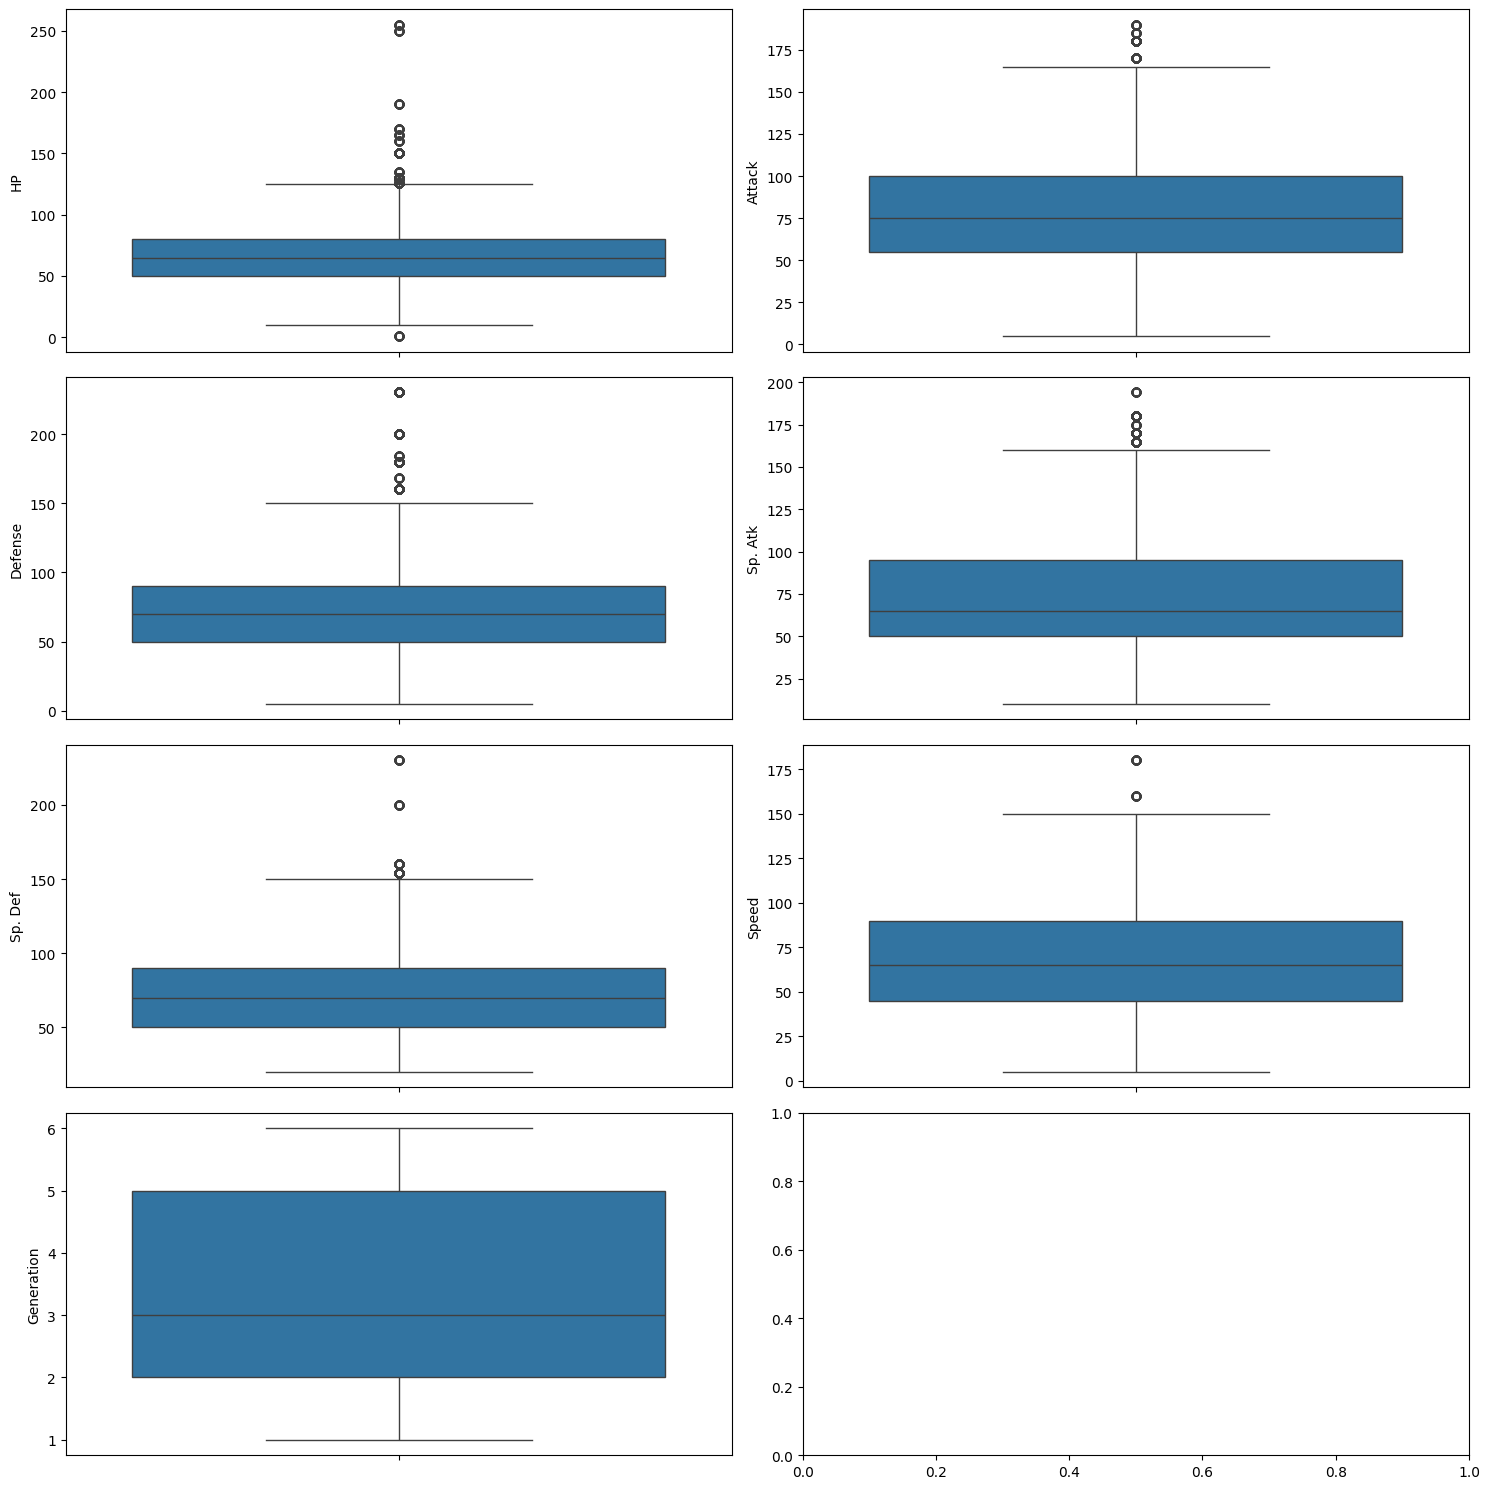

In [21]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (15,15))
sns.boxplot(df['HP'], ax = ax[0,0])
sns.boxplot(df['Attack'], ax = ax[0,1])
sns.boxplot(df['Defense'], ax = ax[1,0])
sns.boxplot(df['Sp. Atk'], ax = ax[1,1])
sns.boxplot(df['Sp. Def'], ax = ax[2,0])
sns.boxplot(df['Speed'], ax = ax[2,1])
sns.boxplot(df['Generation'], ax = ax[3,0])
plt.tight_layout()
plt.show()

On remarque qu'ils y a des outliers dans les variables HP, Attack, Dafense, Sp Atk, Sp Def et Speed

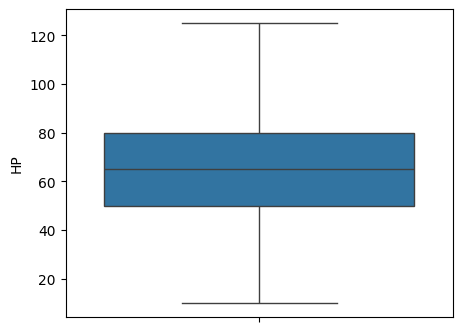

In [22]:
plt.figure(figsize = (5,4))
sns.boxplot(df[(df['HP']>2) & (df['HP']<126)]['HP']) # Vérification du seuil de suppression
plt.show()

In [23]:
df = df[(df['HP']>2) & (df['HP']<126)]

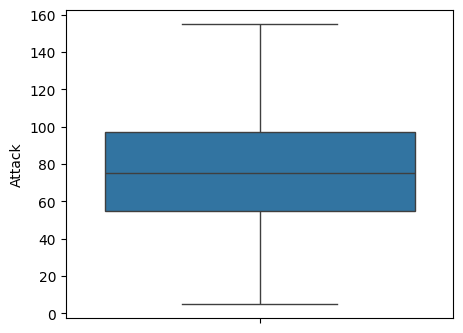

In [24]:
plt.figure(figsize = (5,4))
sns.boxplot(df[df['Attack']<160]['Attack']) # Vérification du seuil de suppression
plt.show()

In [25]:
df = df[df['Attack']<160]

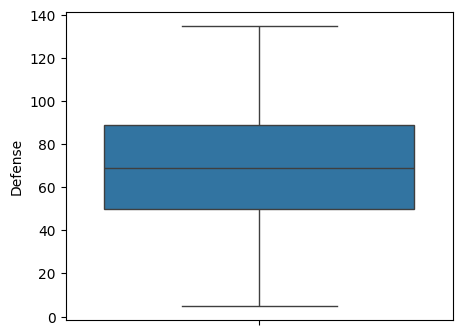

In [26]:
plt.figure(figsize = (5,4))
sns.boxplot(df[df['Defense']<140]['Defense']) # Vérification du seuil de suppression
plt.show()

In [27]:
df = df[df['Defense']<140]

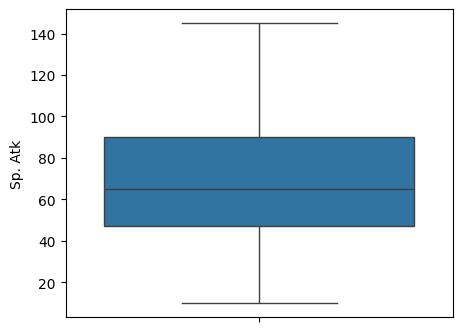

In [28]:
plt.figure(figsize = (5,4))
sns.boxplot(df[df['Sp. Atk']<150]['Sp. Atk']) # Vérification du seuil de suppression
plt.show()

In [29]:
df = df[df['Sp. Atk']<150]

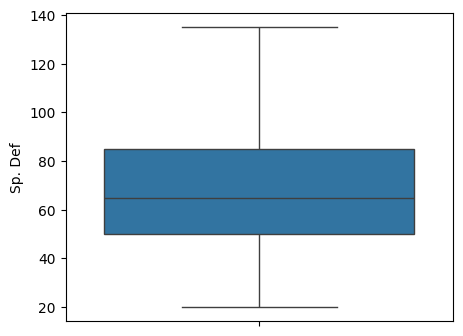

In [30]:
plt.figure(figsize = (5,4))
sns.boxplot(df[df['Sp. Def']< 140]['Sp. Def']) # Vérification du seuil de suppression
plt.show()

In [31]:
df = df[df['Sp. Def']< 140]

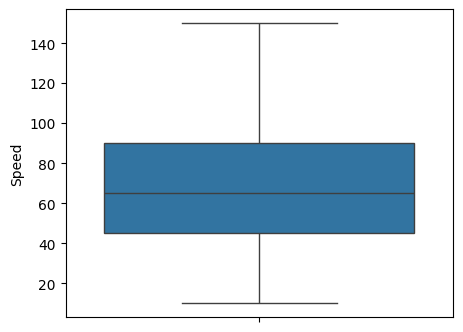

In [32]:
plt.figure(figsize = (5,4))
sns.boxplot(df[df['Speed']<160]['Speed']) # Vérification du seuil de suppression
plt.show()

In [33]:
df = df[df['Speed']<160]

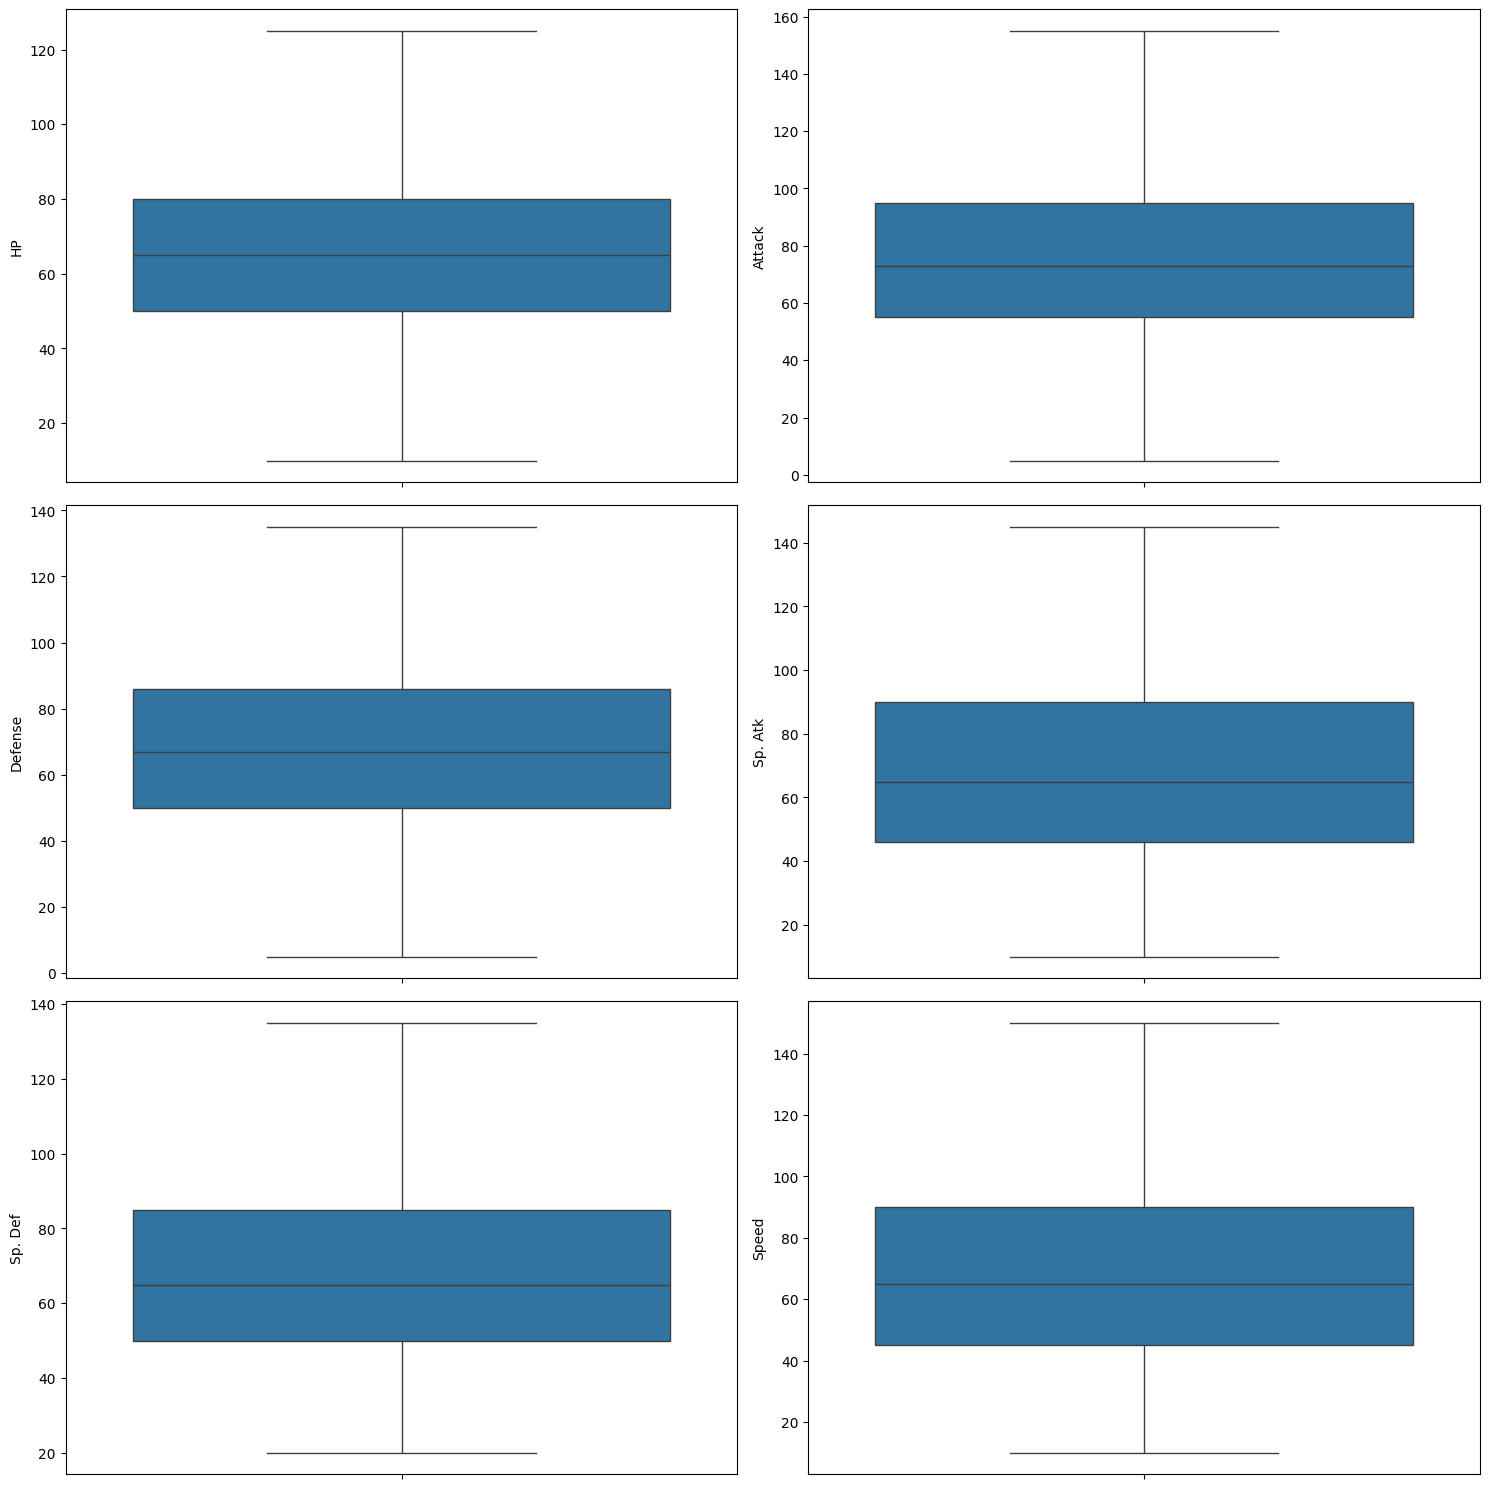

In [34]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (15,15))
sns.boxplot(df['HP'], ax = ax[0,0])
sns.boxplot(df['Attack'], ax = ax[0,1])
sns.boxplot(df['Defense'], ax = ax[1,0])
sns.boxplot(df['Sp. Atk'], ax = ax[1,1])
sns.boxplot(df['Sp. Def'], ax = ax[2,0])
sns.boxplot(df['Speed'], ax = ax[2,1])
plt.tight_layout()
plt.show()

Nos données sont enfin prêt pour l'analyse

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42789 entries, 0 to 49998
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   First_pokemon   42789 non-null  int64 
 1   Second_pokemon  42789 non-null  int64 
 2   Winner          42789 non-null  int64 
 3   #               42789 non-null  int64 
 4   Name            42789 non-null  object
 5   Type 1          42789 non-null  object
 6   Type 2          42789 non-null  object
 7   HP              42789 non-null  int64 
 8   Attack          42789 non-null  int64 
 9   Defense         42789 non-null  int64 
 10  Sp. Atk         42789 non-null  int64 
 11  Sp. Def         42789 non-null  int64 
 12  Speed           42789 non-null  int64 
 13  Generation      42789 non-null  int64 
 14  Legendary       42789 non-null  bool  
dtypes: bool(1), int64(11), object(3)
memory usage: 4.9+ MB


### **Taux de victoire**

#### **Nombre de combat par pokemon**

In [36]:
nb_combat = pd.concat([df['First_pokemon'], df['Second_pokemon']]).value_counts() #On fusionne tous les pokemons

In [37]:
nb_combat.head()

,count
344,147
690,146
53,145
214,144
762,144


#### **Nombre de victoire**

In [38]:
nb_victoire = df['Winner'].value_counts() #On récupère tout les pokemons vaiqueurs d'un combat et on les comptes
nb_victoire.head()

,count
Winner,
154,127
438,127
428,123
394,120
340,117


#### **Calcul du pourcentage de victoire**

In [39]:
percent = pd.DataFrame({
    'combats': nb_combat,
    'victoires': nb_victoire
}).fillna(0)

percent['win_rate'] = round(
    (
    percent['victoires'] / percent['combats']
) * 100,2
)
percent['victoires'] = percent['victoires'].astype(int)

In [40]:
percent.head()

,combats,victoires,win_rate
1,119,34,28.57
2,104,38,36.54
3,119,79,66.39
4,114,64,56.14
5,103,51,49.51


In [41]:
percent.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 1 to 800
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   combats    784 non-null    int64  
 1   victoires  784 non-null    int64  
 2   win_rate   784 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 24.5 KB


On obtient 784 pokemons après regroupement (on récupère leur id), pour chaque pokemon on a le combre de combat, de victoire et le taux de victoire

#### **Ajout de pourcentage au dataset Pokémon**

In [42]:
df = df.merge(
    percent[['win_rate']],
    left_on='#',
    right_index=True,
    how='left'
)

In [43]:
df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,win_rate
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,21.65
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,True,89.91
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,False,21.43
3,237,683,683,237,Slugma,Fire,Aucun,40,40,40,70,40,20,2,False,3.57
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,False,36.29


In [44]:
df[df["win_rate"] == 21.65].head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,win_rate
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,21.65
564,266,301,301,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,21.65
1243,266,304,266,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,21.65
2156,266,247,247,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,21.65
3232,266,690,690,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,False,21.65


In [ ]:
df[['#', 'Name', 'win_rate']].sort_values(by='win_rate', ascending=False).drop_duplicates().head(10)

,#,Name,win_rate
47160,155,Mega Aerodactyl,99.15
39113,704,Tornadus Therian Forme,97.32
6329,513,Weavile,97.27
38205,154,Aerodactyl,96.95
47314,20,Mega Beedrill,96.43


On peut voir ici les 5 meilleures pokemons par pourcentage de victoire

## **Exploratory Analysis & Visualization**

### **Exploratory Analysis**

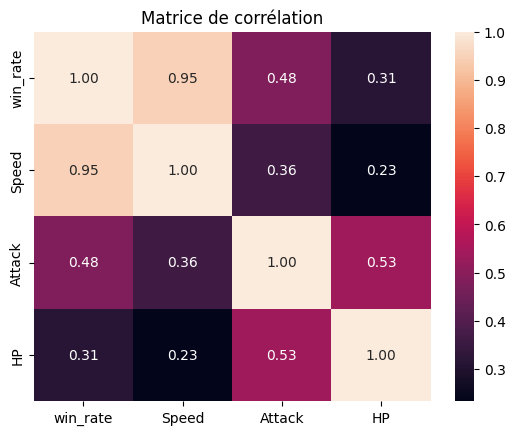

In [46]:
# Calculate the correlation matrix
corr_matrix = df[['HP','Attack','Speed','win_rate']].drop_duplicates().corr()

# Sort features by their absolute correlation with 'num'
sorted_features = corr_matrix['win_rate'].abs().sort_values(ascending=False).index

# Reorder the correlation matrix based on sorted features
sorted_corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

sns.heatmap(sorted_corr_matrix, annot=True, fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()

On remarque qu'il y a une forte corrélation entre la vitesse du pokemon et le pourcentage de victoire, donc plus le pokemon est rapide, plus il a de chanche de gagner

<Figure size 1000x600 with 0 Axes>

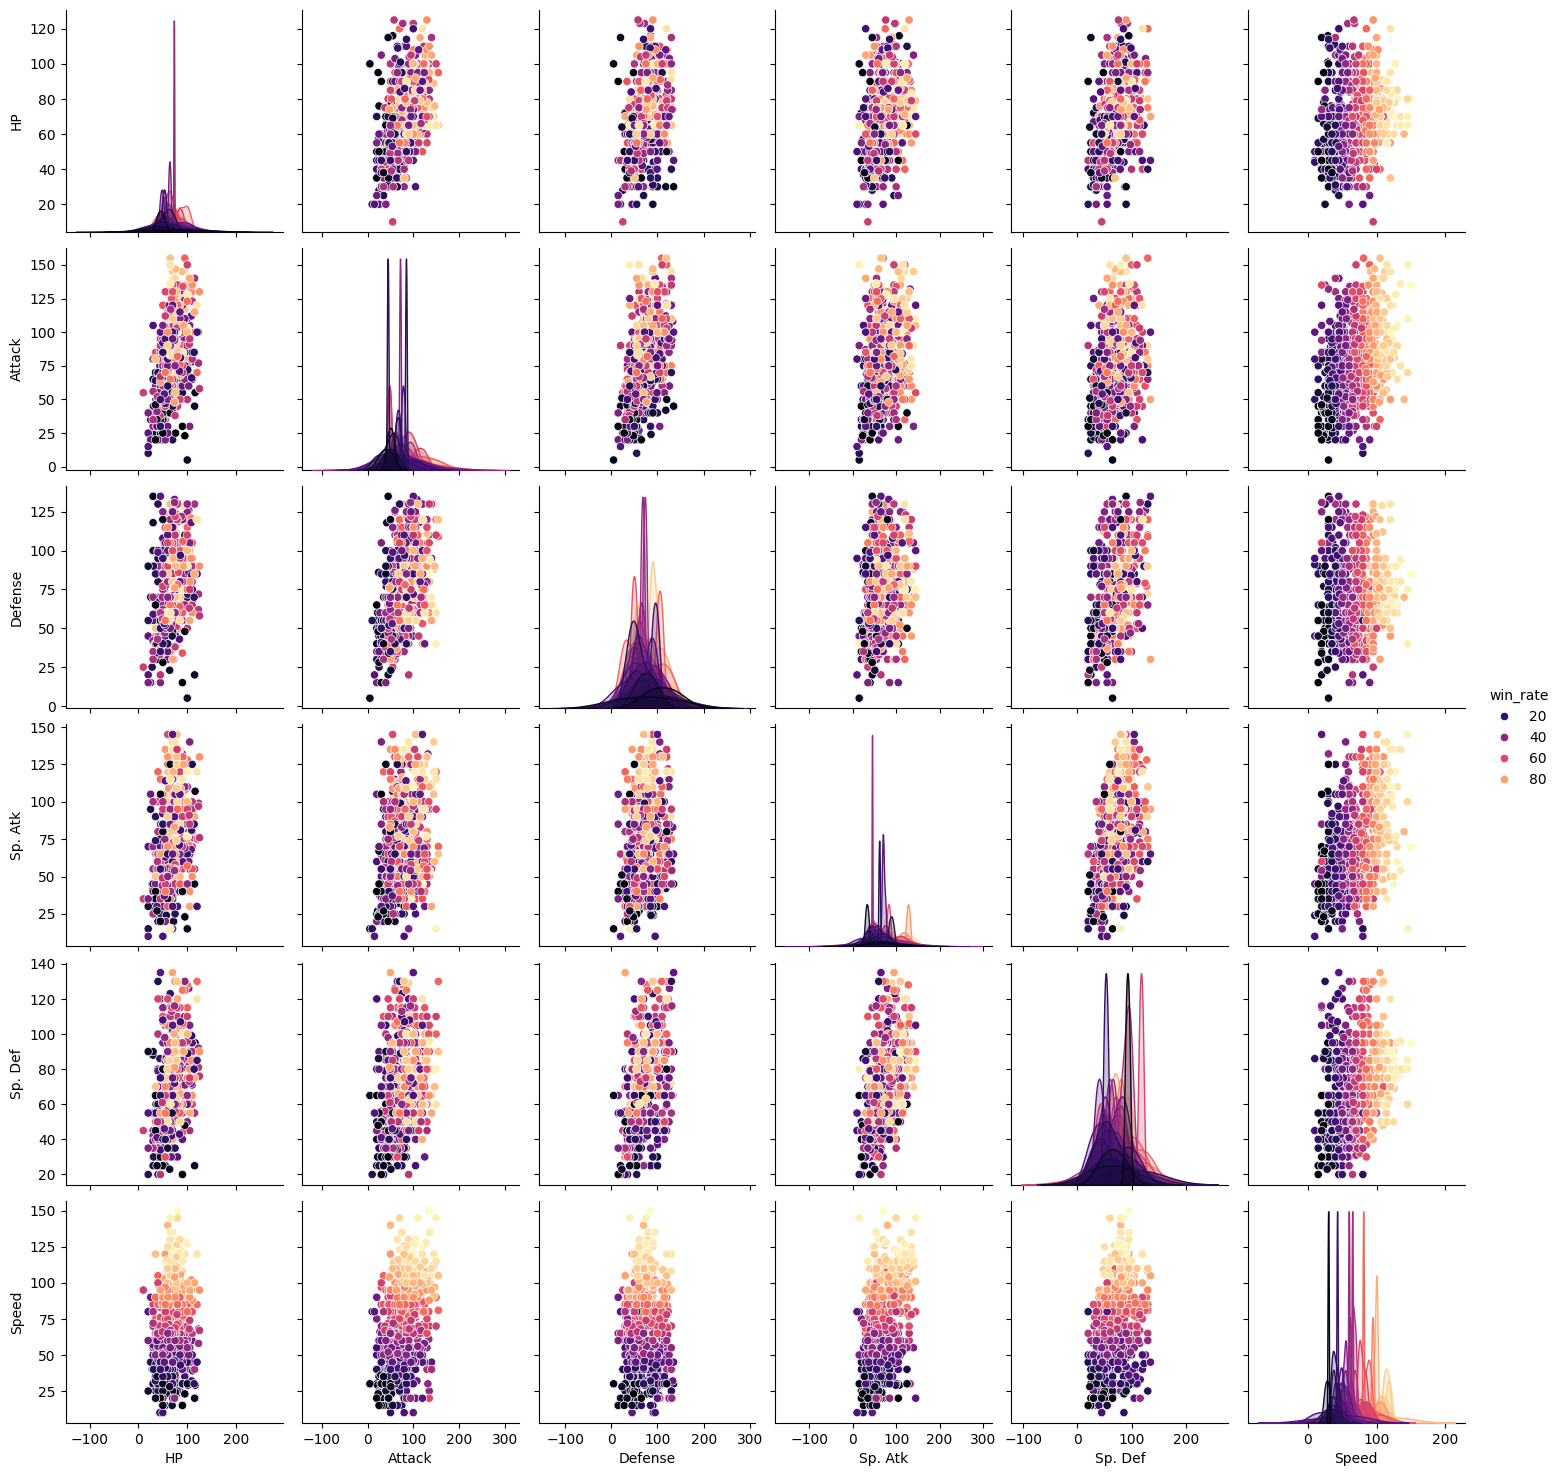

In [47]:
new_df = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'win_rate']].drop_duplicates()

plt.figure(figsize=(10, 6))
sns.pairplot(new_df,hue='win_rate',palette="magma")
plt.show();

Nous avons dis précedemment que la vitesse du pokemon avait un impact sur son taux de victoire. Sur ce plan on peut facilement que la vitesse joue un role important pour le pokemon contrairement aux autres caratéristiques comme l'attaque et le HP

## **Feature section for ML**

In [48]:
df.pivot_table(
    values='win_rate',
    index='Type 1',
    columns='Legendary',
    aggfunc='mean',
    observed=True
).sort_values(by=True, ascending=False)

Legendary,False,True
Type 1,,
Normal,53.390778,93.690000
Dark,61.269294,93.460000
Grass,42.049623,90.906649
Flying,61.580233,90.895000
Steel,33.297403,90.196842
Ground,50.190243,87.493672
Rock,38.793397,86.090000
Electric,61.827743,86.043437
Dragon,53.586362,78.067342


On constate que :

* Les Pokémon légendaires ont presque toujours un taux de victoire très supérieur.
* L'écart est souvent de 20 à 50 points de pourcentage.
* Certains types faibles chez les non-légendaires (Steel, Rock, Grass) deviennent extrêmement performants chez les légendaires.

Cette variable peut-être importante pour notre algorithme de ML

In [49]:
df.groupby('Type 1',observed=True)['win_rate'].mean().sort_values(ascending=False)

,win_rate
Type 1,
Flying,74.938861
Electric,64.000076
Dark,62.199977
Dragon,58.786627
Fire,57.308624
Normal,53.859201
Ground,52.945488
Psychic,47.739563
Fighting,46.431289


On constate que le type du pokemon peut jouer sur son pourcentage de victoire, les pokemons de type Flyng ont un meilleur pourcentage de victoire de les autres pokemon

In [50]:
df['Legendary'] = df['Legendary'].map(
    {
        False: 0,
        True: 1
    }
)

In [51]:
df['Legendary'].unique()

array([0, 1])

In [52]:
df.head()

,First_pokemon,Second_pokemon,Winner,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,win_rate
0,266,298,298,266,Larvitar,Rock,Ground,50,64,50,45,50,41,2,0,21.65
1,702,701,701,702,Virizion,Grass,Fighting,91,90,72,90,129,108,5,1,89.91
2,191,668,668,191,Togetic,Fairy,Flying,55,40,85,80,105,40,2,0,21.43
3,237,683,683,237,Slugma,Fire,Aucun,40,40,40,70,40,20,2,0,3.57
4,151,231,151,151,Omastar,Rock,Water,70,60,125,115,70,55,1,0,36.29


In [53]:
ml_df = df[['HP','Type 1','Type 2','Attack','Defense','Sp. Atk','Sp. Def','Speed','Generation','Legendary','win_rate']] #On recupère les variables qui vont servir à nos prédictions

## **Machine Learning**

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         ['Type 1', 'Type 2']),
        ('num', StandardScaler(), ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed','Generation'])
    ],
    remainder='passthrough'
) #processeur va nous permettre de faire deux choses à la fois, catégoriser le type des pokemon et normaliser HP, Attack.... pour les rendre tous à la même échelle

In [55]:
X = ml_df.drop('win_rate', axis=1) #Selection des variables d'entrainent et de test
y = ml_df['win_rate'] #selection de la variables cible

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Division de nos données en teste et entrainement

In [58]:
regressors = {
    "Linear Regression": LinearRegression(),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42)
} #Initialisation des modèles qu'on utiliseras

results = {}

for name, regressor in regressors.items(): #pour chaque model qu'on parcours, on l'entraine sur nos données d'entrainement (catégoriser et normaliser)
    print(f"\nEntrainement de {name}...")
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = round(mean_absolute_error(y_test, y_pred),4)

    results[name] = {'MAE': mae}

    print(f'{name} - Mean Absolute Error (MAE): {mae}')

print("\nComparaison des modèles")
for name, metrics in results.items():
    print(f"{name}: MAE={metrics['MAE']}")


Entrainement de Linear Regression...
Linear Regression - Mean Absolute Error (MAE): 4.8336

Entrainement de XGBoost Regressor...
XGBoost Regressor - Mean Absolute Error (MAE): 0.1488

Entrainement de Random Forest Regressor...
Random Forest Regressor - Mean Absolute Error (MAE): 0.0172

Comparaison des modèles
Linear Regression: MAE=4.8336
XGBoost Regressor: MAE=0.1488
Random Forest Regressor: MAE=0.0172


On constate que le Random Forest Regressor est le modèle avec la meilleure MAE